# H1N1 and Seasonal Flu Vaccines

## Project Overview

This project focuses on whether individuals received the H1NI flu vaccine (or alternatively the seasonal flu vaccine) using data from the National 2009 H1N1 Flu Survey. The dataset contain demographic information, health-related behaviours and public perceptions about the vaccines. 
The goal is to build a binary classification modelthat estimates the probability of vaccination for each individual.By analyzing patterns in the data, the model will identify key factors influencing vaccination uptake. This project is especially relevant in the context of global vaccination campaigns, where understanding public behaviourcan help improve vaccine distribution strategies, increase uptake and reduce the spread of infectious diseases.

## Business Understanding

Vaccination is a critical tool in controlling infectous diseses, but uptake often varies across populations due to differences in beleifs, access, awareness, and socio-demographic factors. Public health organizations face challenges such as:
- Vaccine hesitancy
- Unequal access to healthcare services
- Misinformation and lack of trust
- Inefficient targeting of high-risk populations

By predicting who is more or less likely to get vaccinated, this project provides data driven insights that can help:
- Target awareness campaigns more effectively
- Allocate resources efficiently
- Design policies to increase vaccination rates
- Identify vulnarable or hesitant groups early

#### Stakeholders

The key stakeholders who will benefit from this project include:
1. Public Health Organizations- Use insights to design vaccines campaigns 
2. Government Policy Makers- Develop policies to improve vaccination coverage 
3. Healthcare Providers and Hospitals- Identify patients who may need encouragement or education 

#### Key Questions

The project seeks to answer the following questions:
1. What factors influence whether a person get vaccinated?
2. Can we accurately predict vaccination behaviour using demographic and behavioural data?
3. Which groups are least likely to receive the vaccine?
4. How do perceptions(e.g risk, trust in vaccines) affect vaccination decisions?
5. What features are strongest predictors of vaccine uptake?

#### Objectives

The main objective of this project is:
- To build a predictive classification model that estimates the likelihood of an individual receiving the H1N1 vaccine or the Seasonal Flu Vaccine.



## Data Understanding

In [115]:
# Importing the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

In [116]:
# Reading the dataset into a pandas dataframe 
df=pd.read_csv("H1N1_Flu_Vaccines.csv")
df.head()

,respondent_id,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,...,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children,employment_industry,employment_occupation,h1n1_vaccine,seasonal_vaccine
0,0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,...,Own,Not in Labor Force,oxchjgsf,Non-MSA,0.0,0.0,NaN,NaN,0,0
1,1,3.0,2.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,...,Rent,Employed,bhuqouqj,"MSA, Not Principle City",0.0,0.0,pxcmvdjn,xgwztkwe,0,1
2,2,1.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",2.0,0.0,rucpziij,xtkaffoo,0,0
3,3,1.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,...,Rent,Not in Labor Force,lrircsnp,"MSA, Principle City",0.0,0.0,NaN,NaN,0,1
4,4,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,...,Own,Employed,qufhixun,"MSA, Not Principle City",1.0,0.0,wxleyezf,emcorrxb,0,0


In [117]:
# chhecking the shape of the dataset
df.shape

(26707, 38)

In [118]:
# checking the infomation of the dataframe
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 26707 entries, 0 to 26706
Data columns (total 38 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   respondent_id                26707 non-null  int64  
 1   h1n1_concern                 26615 non-null  float64
 2   h1n1_knowledge               26591 non-null  float64
 3   behavioral_antiviral_meds    26636 non-null  float64
 4   behavioral_avoidance         26499 non-null  float64
 5   behavioral_face_mask         26688 non-null  float64
 6   behavioral_wash_hands        26665 non-null  float64
 7   behavioral_large_gatherings  26620 non-null  float64
 8   behavioral_outside_home      26625 non-null  float64
 9   behavioral_touch_face        26579 non-null  float64
 10  doctor_recc_h1n1             24547 non-null  float64
 11  doctor_recc_seasonal         24547 non-null  float64
 12  chronic_med_condition        25736 non-null  float64
 13  child_under_6_months       

In [119]:
# checking the missing values 
df.isna().sum().sort_values(ascending=False)

employment_occupation          13470
employment_industry            13330
health_insurance               12274
income_poverty                  4423
doctor_recc_seasonal            2160
doctor_recc_h1n1                2160
rent_or_own                     2042
employment_status               1463
marital_status                  1408
education                       1407
chronic_med_condition            971
child_under_6_months             820
health_worker                    804
opinion_seas_sick_from_vacc      537
opinion_seas_risk                514
opinion_seas_vacc_effective      462
opinion_h1n1_sick_from_vacc      395
opinion_h1n1_vacc_effective      391
opinion_h1n1_risk                388
household_children               249
household_adults                 249
behavioral_avoidance             208
behavioral_touch_face            128
h1n1_knowledge                   116
h1n1_concern                      92
behavioral_large_gatherings       87
behavioral_outside_home           82
b

In [120]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
respondent_id,26707.0,13353.000000,7709.791156,0.0,6676.5,13353.0,20029.5,26706.0
h1n1_concern,26615.0,1.618486,0.910311,0.0,1.0,2.0,2.0,3.0
h1n1_knowledge,26591.0,1.262532,0.618149,0.0,1.0,1.0,2.0,2.0
behavioral_antiviral_meds,26636.0,0.048844,0.215545,0.0,0.0,0.0,0.0,1.0
behavioral_avoidance,26499.0,0.725612,0.446214,0.0,0.0,1.0,1.0,1.0
behavioral_face_mask,26688.0,0.068982,0.253429,0.0,0.0,0.0,0.0,1.0
behavioral_wash_hands,26665.0,0.825614,0.379448,0.0,1.0,1.0,1.0,1.0
behavioral_large_gatherings,26620.0,0.358640,0.479610,0.0,0.0,0.0,1.0,1.0
behavioral_outside_home,26625.0,0.337315,0.472802,0.0,0.0,0.0,1.0,1.0
behavioral_touch_face,26579.0,0.677264,0.467531,0.0,0.0,1.0,1.0,1.0


In [121]:
# Find the duplicated rows
df.duplicated().sum()

np.int64(0)

In [122]:
print(df["h1n1_vaccine"].value_counts())
print(df["seasonal_vaccine"].value_counts())

h1n1_vaccine
0    21033
1     5674
Name: count, dtype: int64
seasonal_vaccine
0    14272
1    12435
Name: count, dtype: int64


From the above output, we can see that the h1n1 vaccine target class is imbalanced. The seasonal vaccine class is more balanced, but we'll have to keep tabs on this once we start modeling. A very small rate of people received both seasonal as well as h1n1 vaccines.

Checking the ratio of people who received both seasonal and h1n1 vaccines, received just one, or received none at all.

In [123]:
# Checking the ratio of people who received both seasonal and h1n1 vaccines, received just one, or received none at all.
only_h1n1 = df[(df["h1n1_vaccine"]==1) & (df["seasonal_vaccine"]==0)].shape[0]/df.shape[0]

only_seasonal = df[(df["h1n1_vaccine"]==0) & (df["seasonal_vaccine"]==1)].shape[0]/df.shape[0]

both = df[(df["h1n1_vaccine"]==1) & (df["seasonal_vaccine"]==1)].shape[0]/df.shape[0]

neither = df[(df["h1n1_vaccine"]==0) & (df["seasonal_vaccine"]==0)].shape[0]/df.shape[0]

# print results
print("Only H1N1:", only_h1n1)
print("Only Seasonal:", only_seasonal)
print("Both Vaccines:", both)
print("Neither:", neither)

Only H1N1: 0.03658216946867862
Only Seasonal: 0.2897367731306399
Both Vaccines: 0.17587149436477328
Neither: 0.4978095630359082


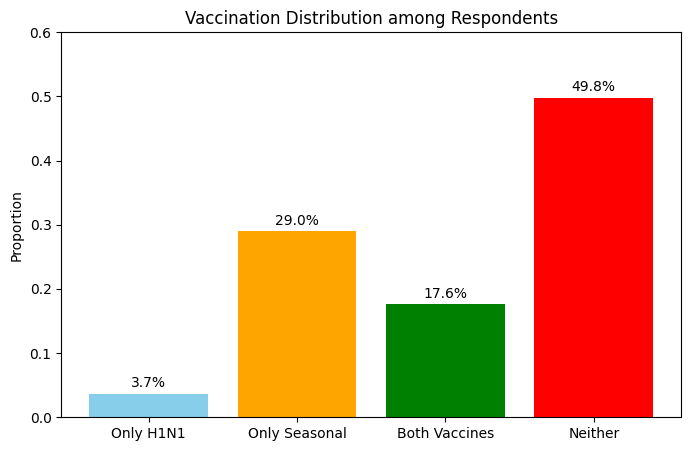

In [124]:
# categories and their proportions
categories = ["Only H1N1", "Only Seasonal", "Both Vaccines", "Neither"]
proportions = [0.0366, 0.2897, 0.1759, 0.4978]

# create bar chart
plt.figure(figsize=(8,5))
bars = plt.bar(categories, proportions, color=['skyblue','orange','green','red'])
plt.title("Vaccination Distribution among Respondents")
plt.ylabel("Proportion")
plt.ylim(0, 0.6)

# add percentage labels on top of bars
for bar, prop in zip(bars, proportions):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, f"{prop*100:.1f}%", ha='center', fontsize=10)

plt.show()



From the above vaccination distribution analysis, about 3.7% of respondents took only the H1N1 vaccine, 29.0% took only the seasonal vaccine, 17.6% took both, and 49.8% took neither, showing that almost half did not receive any vaccine.

### Class Distribution

In [125]:
# checking the class distribution for the target variable
print(df["h1n1_vaccine"].value_counts())
print(df["seasonal_vaccine"].value_counts())

h1n1_vaccine
0    21033
1     5674
Name: count, dtype: int64
seasonal_vaccine
0    14272
1    12435
Name: count, dtype: int64


## 3. Data preparation

##### Dropping Columns with Many Missing Values

In this step, we remove columns that contain a large number of missing values.


In [126]:
# drop the columns with many missing values 
df.drop(["employment_occupation", "employment_industry", "health_insurance", "respondent_id"], axis=1, inplace=True)

##### Splitting Features and Target Variables

In this step, we separate the dataset into input features (`X`) and target variables (`y`).

In [127]:
x=df.drop(["h1n1_vaccine", "seasonal_vaccine"], axis=1)
y=df["h1n1_vaccine"]

##### Splitting the Dataset into Training and Testing Sets

The dataset is divided into training and testing sets to evaluate the model's performance.

In [128]:
# splitting the dataset into training and testing
x_train, x_test, y_train, y_test=train_test_split(x,y, test_size=0.3, random_state=42)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((18694, 32), (8013, 32), (18694,), (8013,))

Data preparation for the x_train

In [129]:
x_train

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,race,sex,income_poverty,marital_status,rent_or_own,employment_status,hhs_geo_region,census_msa,household_adults,household_children
5303,2.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,White,Male,"> $75,000",Married,Own,Not in Labor Force,atmpeygn,"MSA, Principle City",1.0,0.0
2703,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,...,Hispanic,Male,Below Poverty,Not Married,Rent,Employed,oxchjgsf,"MSA, Principle City",1.0,0.0
6586,3.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,White,Female,"> $75,000",Not Married,Rent,Employed,fpwskwrf,"MSA, Not Principle City",2.0,0.0
22563,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,White,Male,"> $75,000",Married,Own,Employed,atmpeygn,"MSA, Principle City",1.0,2.0
2338,0.0,2.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,...,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Not in Labor Force,kbazzjca,"MSA, Not Principle City",0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21575,2.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,White,Male,"> $75,000",Not Married,Own,Not in Labor Force,qufhixun,"MSA, Principle City",0.0,0.0
5390,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,NaN,...,White,Male,"<= $75,000, Above Poverty",Not Married,Own,Unemployed,mlyzmhmf,"MSA, Principle City",0.0,0.0
860,2.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,White,Female,"<= $75,000, Above Poverty",Married,Own,Employed,qufhixun,Non-MSA,1.0,0.0
15795,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,...,Black,Female,"> $75,000",Married,Own,Employed,kbazzjca,"MSA, Principle City",1.0,0.0


In [130]:
# checking for missing values in the x_train dataset
x_train.isna().sum()

h1n1_concern                     64
h1n1_knowledge                   82
behavioral_antiviral_meds        50
behavioral_avoidance            150
behavioral_face_mask             14
behavioral_wash_hands            34
behavioral_large_gatherings      65
behavioral_outside_home          55
behavioral_touch_face            86
doctor_recc_h1n1               1532
doctor_recc_seasonal           1532
chronic_med_condition           667
child_under_6_months            561
health_worker                   554
opinion_h1n1_vacc_effective     277
opinion_h1n1_risk               268
opinion_h1n1_sick_from_vacc     275
opinion_seas_vacc_effective     321
opinion_seas_risk               355
opinion_seas_sick_from_vacc     377
age_group                         0
education                       970
race                              0
sex                               0
income_poverty                 3046
marital_status                  964
rent_or_own                    1413
employment_status           

#### Handling missing values for the x_train

Ordinal numerical columns

In [131]:
# handling missing values for the numerical columns
x_train.select_dtypes("float64").isna().sum()

h1n1_concern                     64
h1n1_knowledge                   82
behavioral_antiviral_meds        50
behavioral_avoidance            150
behavioral_face_mask             14
behavioral_wash_hands            34
behavioral_large_gatherings      65
behavioral_outside_home          55
behavioral_touch_face            86
doctor_recc_h1n1               1532
doctor_recc_seasonal           1532
chronic_med_condition           667
child_under_6_months            561
health_worker                   554
opinion_h1n1_vacc_effective     277
opinion_h1n1_risk               268
opinion_h1n1_sick_from_vacc     275
opinion_seas_vacc_effective     321
opinion_seas_risk               355
opinion_seas_sick_from_vacc     377
household_adults                179
household_children              179
dtype: int64


All the ordinal numerical columns in the dataset contain missing values. These were handled using **mode imputation**, where each missing value was replaced with the most frequent value in its respective column.

This method is appropriate because ordinal features represent ordered categories, and using the mode helps preserve the most common and meaningful responses without changing the data.

In [132]:
# selecting the x_train columns with float data types
x_train_float=x_train.select_dtypes('float64')

# initializing the simple imputer class and using the mode strategy to fill the missing values
imputer=SimpleImputer(strategy="most_frequent")
filled_float=pd.DataFrame(imputer.fit_transform(x_train_float), index=x_train_float.index, 
                          columns=x_train_float.columns)

x_train_float= filled_float
x_train_float.isna().sum()

h1n1_concern                   0
h1n1_knowledge                 0
behavioral_antiviral_meds      0
behavioral_avoidance           0
behavioral_face_mask           0
behavioral_wash_hands          0
behavioral_large_gatherings    0
behavioral_outside_home        0
behavioral_touch_face          0
doctor_recc_h1n1               0
doctor_recc_seasonal           0
chronic_med_condition          0
child_under_6_months           0
health_worker                  0
opinion_h1n1_vacc_effective    0
opinion_h1n1_risk              0
opinion_h1n1_sick_from_vacc    0
opinion_seas_vacc_effective    0
opinion_seas_risk              0
opinion_seas_sick_from_vacc    0
household_adults               0
household_children             0
dtype: int64

#### Handling missing values for the categorical columns


Some categorical columns in the dataset contain missing values. These were handled using **mode imputation**, where each missing value was replaced with the most frequent value in its respective column.



In [133]:
# selecting the x_train columns with string data types
x_train_cat= x_train.select_dtypes("object")

# creating a variable called cat_cols that has the columns with the missing values
cat_cols=x_train_cat[["education","income_poverty", "marital_status","rent_or_own","employment_status"]]

# filling the missing values with the mode strategy using the simpleimputer method
cat_cols_filled=pd.DataFrame(imputer.fit_transform(cat_cols), index=cat_cols.index, 
                        columns=cat_cols.columns)

x_train_cat_filled= cat_cols_filled

x_train_cat_filled.isna().sum()

C:\Users\hp\AppData\Local\Temp\ipykernel_1932\2867867911.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  x_train_cat= x_train.select_dtypes("object")


education            0
income_poverty       0
marital_status       0
rent_or_own          0
employment_status    0
dtype: int64

In [134]:
x_train_cat.isna().sum()

age_group               0
education             970
race                    0
sex                     0
income_poverty       3046
marital_status        964
rent_or_own          1413
employment_status    1005
hhs_geo_region          0
census_msa              0
dtype: int64

In [135]:
# Concatinating the filled columnst to form one x_train dataframe 
x_train_full=pd.concat([x_train_float, x_train_cat_filled, 
                       x_train_cat[["age_group", "race","sex","census_msa","hhs_geo_region"]]], axis=1)

x_train_full

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,education,income_poverty,marital_status,rent_or_own,employment_status,age_group,race,sex,census_msa,hhs_geo_region
5303,2.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,College Graduate,"> $75,000",Married,Own,Not in Labor Force,65+ Years,White,Male,"MSA, Principle City",atmpeygn
2703,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,...,12 Years,Below Poverty,Not Married,Rent,Employed,18 - 34 Years,Hispanic,Male,"MSA, Principle City",oxchjgsf
6586,3.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,College Graduate,"> $75,000",Not Married,Rent,Employed,45 - 54 Years,White,Female,"MSA, Not Principle City",fpwskwrf
22563,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,College Graduate,"> $75,000",Married,Own,Employed,18 - 34 Years,White,Male,"MSA, Principle City",atmpeygn
2338,0.0,2.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,...,College Graduate,"<= $75,000, Above Poverty",Not Married,Own,Not in Labor Force,65+ Years,White,Male,"MSA, Not Principle City",kbazzjca
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21575,2.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,Some College,"> $75,000",Not Married,Own,Not in Labor Force,55 - 64 Years,White,Male,"MSA, Principle City",qufhixun
5390,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,Some College,"<= $75,000, Above Poverty",Not Married,Own,Unemployed,55 - 64 Years,White,Male,"MSA, Principle City",mlyzmhmf
860,2.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,...,12 Years,"<= $75,000, Above Poverty",Married,Own,Employed,55 - 64 Years,White,Female,Non-MSA,qufhixun
15795,2.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,...,College Graduate,"> $75,000",Married,Own,Employed,35 - 44 Years,Black,Female,"MSA, Principle City",kbazzjca


### Handling the missing values for the x_test

In [136]:
x_test.isna().sum().sort_values(ascending=False)

income_poverty                 1377
rent_or_own                     629
doctor_recc_seasonal            628
doctor_recc_h1n1                628
employment_status               458
marital_status                  444
education                       437
chronic_med_condition           304
child_under_6_months            259
health_worker                   250
opinion_seas_sick_from_vacc     160
opinion_seas_risk               159
opinion_seas_vacc_effective     141
opinion_h1n1_risk               120
opinion_h1n1_sick_from_vacc     120
opinion_h1n1_vacc_effective     114
household_adults                 70
household_children               70
behavioral_avoidance             58
behavioral_touch_face            42
h1n1_knowledge                   34
h1n1_concern                     28
behavioral_outside_home          27
behavioral_large_gatherings      22
behavioral_antiviral_meds        21
behavioral_wash_hands             8
behavioral_face_mask              5
age_group                   

#### Handling the ordinal numerical columns



In [137]:
# selecting the x_test columns with float data types
x_test_float=x_test.select_dtypes("float64")
x_test_float.isna().sum()

h1n1_concern                    28
h1n1_knowledge                  34
behavioral_antiviral_meds       21
behavioral_avoidance            58
behavioral_face_mask             5
behavioral_wash_hands            8
behavioral_large_gatherings     22
behavioral_outside_home         27
behavioral_touch_face           42
doctor_recc_h1n1               628
doctor_recc_seasonal           628
chronic_med_condition          304
child_under_6_months           259
health_worker                  250
opinion_h1n1_vacc_effective    114
opinion_h1n1_risk              120
opinion_h1n1_sick_from_vacc    120
opinion_seas_vacc_effective    141
opinion_seas_risk              159
opinion_seas_sick_from_vacc    160
household_adults                70
household_children              70
dtype: int64

In [138]:
# initializing the simple imputer class and using the mode strategy to fill the missing values
imputer=SimpleImputer(strategy="most_frequent")
x_test_filled_float=pd.DataFrame(imputer.fit_transform(x_test_float), index=x_test_float.index, 
                          columns=x_test_float.columns)

x_test_float= x_test_filled_float
x_test_float.isna().sum()

h1n1_concern                   0
h1n1_knowledge                 0
behavioral_antiviral_meds      0
behavioral_avoidance           0
behavioral_face_mask           0
behavioral_wash_hands          0
behavioral_large_gatherings    0
behavioral_outside_home        0
behavioral_touch_face          0
doctor_recc_h1n1               0
doctor_recc_seasonal           0
chronic_med_condition          0
child_under_6_months           0
health_worker                  0
opinion_h1n1_vacc_effective    0
opinion_h1n1_risk              0
opinion_h1n1_sick_from_vacc    0
opinion_seas_vacc_effective    0
opinion_seas_risk              0
opinion_seas_sick_from_vacc    0
household_adults               0
household_children             0
dtype: int64

In [139]:
# selecting the x_train columns with string data types
x_test_cat=x_test.select_dtypes("object")
x_test_cat.isna().sum()

C:\Users\hp\AppData\Local\Temp\ipykernel_1932\3702225047.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  x_test_cat=x_test.select_dtypes("object")


age_group               0
education             437
race                    0
sex                     0
income_poverty       1377
marital_status        444
rent_or_own           629
employment_status     458
hhs_geo_region          0
census_msa              0
dtype: int64

In [140]:
# creating a variable called cat_cols that has the columns with the missing values
cat_cols=x_test_cat[["education","income_poverty", "marital_status","rent_or_own","employment_status"]]

# filling the missing values with the mode strategy using the simpleimputer method
cat_cols_filled=pd.DataFrame(imputer.fit_transform(cat_cols), index=cat_cols.index, 
                        columns=cat_cols.columns)

x_test_cat_filled= cat_cols_filled

x_test_cat_filled.isna().sum()

education            0
income_poverty       0
marital_status       0
rent_or_own          0
employment_status    0
dtype: int64

In [141]:
# Concatinating the filled columnst to form one x_train dataframe 
x_test_full=pd.concat([x_test_float, x_test_cat_filled, 
                       x_test_cat[["age_group", "race","sex","census_msa","hhs_geo_region"]]], axis=1)

x_test_full.head()

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,education,income_poverty,marital_status,rent_or_own,employment_status,age_group,race,sex,census_msa,hhs_geo_region
15772,2.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,College Graduate,"<= $75,000, Above Poverty",Married,Own,Employed,18 - 34 Years,White,Female,"MSA, Principle City",atmpeygn
9407,3.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,...,College Graduate,"<= $75,000, Above Poverty",Married,Own,Employed,35 - 44 Years,White,Male,"MSA, Principle City",fpwskwrf
16515,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,...,College Graduate,"<= $75,000, Above Poverty",Not Married,Own,Employed,45 - 54 Years,White,Female,"MSA, Not Principle City",atmpeygn
23353,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,College Graduate,"> $75,000",Married,Own,Employed,35 - 44 Years,White,Female,Non-MSA,bhuqouqj
10008,1.0,2.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,...,College Graduate,"> $75,000",Married,Own,Employed,55 - 64 Years,White,Male,"MSA, Principle City",lrircsnp


In [142]:
x_test_full.isna().sum()

h1n1_concern                   0
h1n1_knowledge                 0
behavioral_antiviral_meds      0
behavioral_avoidance           0
behavioral_face_mask           0
behavioral_wash_hands          0
behavioral_large_gatherings    0
behavioral_outside_home        0
behavioral_touch_face          0
doctor_recc_h1n1               0
doctor_recc_seasonal           0
chronic_med_condition          0
child_under_6_months           0
health_worker                  0
opinion_h1n1_vacc_effective    0
opinion_h1n1_risk              0
opinion_h1n1_sick_from_vacc    0
opinion_seas_vacc_effective    0
opinion_seas_risk              0
opinion_seas_sick_from_vacc    0
household_adults               0
household_children             0
education                      0
income_poverty                 0
marital_status                 0
rent_or_own                    0
employment_status              0
age_group                      0
race                           0
sex                            0
census_msa

### Mapping the Categorical columns

Mapping the train columns

In [143]:
x_train_full["education"].unique()

<StringArray>
['College Graduate', '12 Years', 'Some College', '< 12 Years']
Length: 4, dtype: str

In [144]:
x_train_full["education"]=x_train_full["education"].replace({"12 Years": "Secondary School", "< 12 Years":"Primary School"})

x_train_full["education"].unique()

<StringArray>
['College Graduate', 'Secondary School', 'Some College', 'Primary School']
Length: 4, dtype: str

In [145]:
x_train_full["income_poverty"].unique()

<StringArray>
['> $75,000', 'Below Poverty', '<= $75,000, Above Poverty']
Length: 3, dtype: str

In [146]:
x_train_full["income_poverty"]=x_train_full["income_poverty"].replace(
    {'> $75,000': "High_income", '<= $75,000, Above Poverty':"Average Income", 'Below Poverty':"Low Income"})

x_train_full["income_poverty"].unique()

<StringArray>
['High_income', 'Low Income', 'Average Income']
Length: 3, dtype: str

Mapping the test data

In [147]:
x_test_full["education"].unique()

<StringArray>
['College Graduate', 'Some College', '12 Years', '< 12 Years']
Length: 4, dtype: str

In [148]:
x_test_full["education"]=x_test_full["education"].replace({"12 Years": "Secondary School", "< 12 Years":"Primary School"})

x_test_full["education"].unique()

<StringArray>
['College Graduate', 'Some College', 'Secondary School', 'Primary School']
Length: 4, dtype: str

In [149]:
x_test_full["income_poverty"].unique()

<StringArray>
['<= $75,000, Above Poverty', '> $75,000', 'Below Poverty']
Length: 3, dtype: str

In [150]:
x_test_full["income_poverty"]=x_test_full["income_poverty"].replace(
    {'> $75,000': "High_income", '<= $75,000, Above Poverty':"Average Income", 'Below Poverty':"Low Income"})

x_test_full["income_poverty"].unique()

<StringArray>
['Average Income', 'High_income', 'Low Income']
Length: 3, dtype: str

In [151]:
x_test_full.head()

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,education,income_poverty,marital_status,rent_or_own,employment_status,age_group,race,sex,census_msa,hhs_geo_region
15772,2.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,...,College Graduate,Average Income,Married,Own,Employed,18 - 34 Years,White,Female,"MSA, Principle City",atmpeygn
9407,3.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,...,College Graduate,Average Income,Married,Own,Employed,35 - 44 Years,White,Male,"MSA, Principle City",fpwskwrf
16515,1.0,1.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,0.0,...,College Graduate,Average Income,Not Married,Own,Employed,45 - 54 Years,White,Female,"MSA, Not Principle City",atmpeygn
23353,2.0,2.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,College Graduate,High_income,Married,Own,Employed,35 - 44 Years,White,Female,Non-MSA,bhuqouqj
10008,1.0,2.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,...,College Graduate,High_income,Married,Own,Employed,55 - 64 Years,White,Male,"MSA, Principle City",lrircsnp


In [152]:
x_train_full.head()

,h1n1_concern,h1n1_knowledge,behavioral_antiviral_meds,behavioral_avoidance,behavioral_face_mask,behavioral_wash_hands,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,...,education,income_poverty,marital_status,rent_or_own,employment_status,age_group,race,sex,census_msa,hhs_geo_region
5303,2.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,...,College Graduate,High_income,Married,Own,Not in Labor Force,65+ Years,White,Male,"MSA, Principle City",atmpeygn
2703,2.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,...,Secondary School,Low Income,Not Married,Rent,Employed,18 - 34 Years,Hispanic,Male,"MSA, Principle City",oxchjgsf
6586,3.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,...,College Graduate,High_income,Not Married,Rent,Employed,45 - 54 Years,White,Female,"MSA, Not Principle City",fpwskwrf
22563,1.0,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,College Graduate,High_income,Married,Own,Employed,18 - 34 Years,White,Male,"MSA, Principle City",atmpeygn
2338,0.0,2.0,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,...,College Graduate,Average Income,Not Married,Own,Not in Labor Force,65+ Years,White,Male,"MSA, Not Principle City",kbazzjca


#### Creating new features: Preventive behavior and Risk score

In [153]:
# Preventive behavior score
x_train_full["preventive_behavior"] = (
    x_train_full["behavioral_antiviral_meds"] +
    x_train_full["behavioral_avoidance"] +
    x_train_full["behavioral_face_mask"] +
    x_train_full["behavioral_wash_hands"]
)

x_test_full["preventive_behavior"] = (
    x_test_full["behavioral_antiviral_meds"] +
    x_test_full["behavioral_avoidance"] +
    x_test_full["behavioral_face_mask"] +
    x_test_full["behavioral_wash_hands"]
)

# Risk perception score
x_train_full["risk_score"] = (
    x_train_full["h1n1_concern"] +
    x_train_full["opinion_h1n1_risk"]
)

x_test_full["risk_score"] = (
    x_test_full["h1n1_concern"] +
    x_test_full["opinion_h1n1_risk"]
)

Two new features were created: preventive_behavior as the sum of behavioral measures, and risk_score as the sum of concern and risk perception variables. 

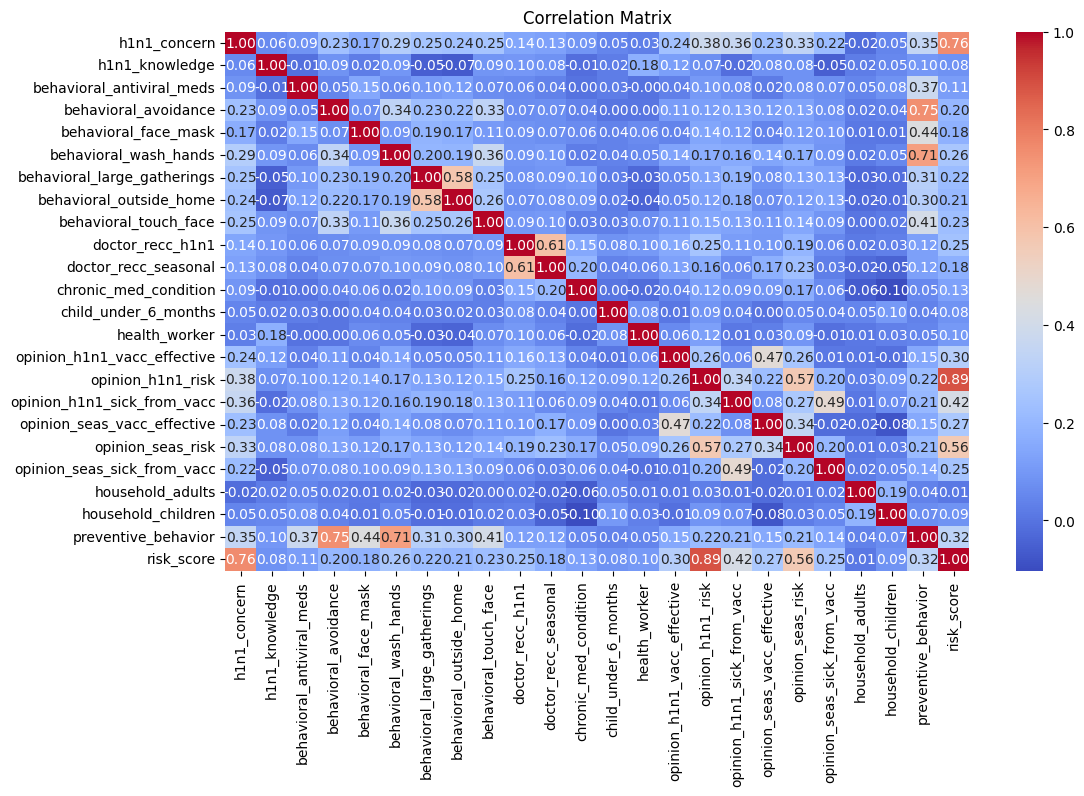

In [154]:
# Keep only numeric columns
numeric_cols = x_train_full.select_dtypes(include='number')

# Compute correlation matrix
corr = numeric_cols.corr()

# Plot heatmap
plt.figure(figsize=(12,7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

A correlation analysis showed that these new features were highly correlated with their original components. To reduce redundancy and multicollinearity, the original columns contributing to these sums need to be dropped. This ensures the dataset is more compact while retaining the key information for modeling.

In [155]:
cols_to_drop = [
    "behavioral_antiviral_meds", 
    "behavioral_avoidance",
    "behavioral_face_mask",
    "behavioral_wash_hands",
    "h1n1_concern",
    "opinion_h1n1_risk"
]

x_train_full = x_train_full.drop(columns=cols_to_drop)
x_test_full = x_test_full.drop(columns=cols_to_drop)

### OneHotEncoding the Categorical columns

One Hot Encoding the train data


In [156]:
x_train.select_dtypes("object").columns

C:\Users\hp\AppData\Local\Temp\ipykernel_1932\377527183.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  x_train.select_dtypes("object").columns


Index(['age_group', 'education', 'race', 'sex', 'income_poverty',
       'marital_status', 'rent_or_own', 'employment_status', 'hhs_geo_region',
       'census_msa'],
      dtype='str')

In [157]:
# Initializing the onehotencoder class
ohe=OneHotEncoder(sparse_output=False)

# creating a variable called ohe_columns that contain the columns to be encoded
ohe_cols=x_train_full[['age_group', 'education', 'race', 'sex', 'income_poverty',
       'marital_status', 'rent_or_own', 'employment_status', 'hhs_geo_region',
       'census_msa']]

x_train_ohe=pd.DataFrame(ohe.fit_transform(ohe_cols), index=x_train_full.index,
                         columns=ohe.get_feature_names_out())
x_train_ohe.head()


,age_group_18 - 34 Years,age_group_35 - 44 Years,age_group_45 - 54 Years,age_group_55 - 64 Years,age_group_65+ Years,education_College Graduate,education_Primary School,education_Secondary School,education_Some College,race_Black,...,hhs_geo_region_fpwskwrf,hhs_geo_region_kbazzjca,hhs_geo_region_lrircsnp,hhs_geo_region_lzgpxyit,hhs_geo_region_mlyzmhmf,hhs_geo_region_oxchjgsf,hhs_geo_region_qufhixun,"census_msa_MSA, Not Principle City","census_msa_MSA, Principle City",census_msa_Non-MSA
5303,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2703,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
6586,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
22563,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2338,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


In [158]:
x_train_full=x_train_full.drop(ohe_cols.columns, axis=1)
x_train_full.head()

,h1n1_knowledge,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,opinion_h1n1_vacc_effective,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,household_adults,household_children,preventive_behavior,risk_score
5303,2.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,4.0,2.0,5.0,2.0,2.0,1.0,0.0,1.0,3.0
2703,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,4.0,4.0,2.0,5.0,1.0,1.0,0.0,2.0,4.0
6586,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,4.0,4.0,5.0,4.0,5.0,2.0,0.0,2.0,5.0
22563,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,4.0,5.0,2.0,4.0,1.0,2.0,0.0,3.0
2338,2.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,5.0,4.0,5.0,4.0,1.0,0.0,0.0,2.0,4.0


In [159]:
X_train_full=pd.concat([x_train_full, x_train_ohe], axis=1)
X_train_full.head()

,h1n1_knowledge,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,opinion_h1n1_vacc_effective,...,hhs_geo_region_fpwskwrf,hhs_geo_region_kbazzjca,hhs_geo_region_lrircsnp,hhs_geo_region_lzgpxyit,hhs_geo_region_mlyzmhmf,hhs_geo_region_oxchjgsf,hhs_geo_region_qufhixun,"census_msa_MSA, Not Principle City","census_msa_MSA, Principle City",census_msa_Non-MSA
5303,2.0,0.0,0.0,0.0,1.0,1.0,1.0,1.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2703,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
6586,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,4.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
22563,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2338,2.0,1.0,1.0,1.0,1.0,1.0,0.0,0.0,0.0,5.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0


One Hot Encoding the test data

In [160]:
x_test.select_dtypes("object").columns

C:\Users\hp\AppData\Local\Temp\ipykernel_1932\3774354464.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  x_test.select_dtypes("object").columns


Index(['age_group', 'education', 'race', 'sex', 'income_poverty',
       'marital_status', 'rent_or_own', 'employment_status', 'hhs_geo_region',
       'census_msa'],
      dtype='str')

In [161]:
# Initializing the onehotencoder class
ohe=OneHotEncoder(sparse_output=False)

# creating a variable called ohe_columns that contain the columns to be encoded
ohe_cols=x_test_full[['age_group', 'education', 'race', 'sex', 'income_poverty',
       'marital_status', 'rent_or_own', 'employment_status', 'hhs_geo_region',
       'census_msa']]

x_test_ohe=pd.DataFrame(ohe.fit_transform(ohe_cols), index=x_test_full.index,
                         columns=ohe.get_feature_names_out())
x_test_ohe


,age_group_18 - 34 Years,age_group_35 - 44 Years,age_group_45 - 54 Years,age_group_55 - 64 Years,age_group_65+ Years,education_College Graduate,education_Primary School,education_Secondary School,education_Some College,race_Black,...,hhs_geo_region_fpwskwrf,hhs_geo_region_kbazzjca,hhs_geo_region_lrircsnp,hhs_geo_region_lzgpxyit,hhs_geo_region_mlyzmhmf,hhs_geo_region_oxchjgsf,hhs_geo_region_qufhixun,"census_msa_MSA, Not Principle City","census_msa_MSA, Principle City",census_msa_Non-MSA
15772,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9407,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
16515,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
23353,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
10008,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19075,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
25430,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
25864,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5874,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [162]:
x_test_full=x_test_full.drop(ohe_cols.columns, axis=1)
x_test_full

,h1n1_knowledge,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,opinion_h1n1_vacc_effective,opinion_h1n1_sick_from_vacc,opinion_seas_vacc_effective,opinion_seas_risk,opinion_seas_sick_from_vacc,household_adults,household_children,preventive_behavior,risk_score
15772,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,4.0,2.0,1.0,1.0,0.0,3.0,4.0
9407,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,1.0,4.0,2.0,1.0,1.0,1.0,3.0,5.0
16515,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,4.0,2.0,4.0,4.0,1.0,0.0,1.0,2.0,3.0
23353,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,2.0,4.0,2.0,1.0,1.0,2.0,2.0,4.0
10008,2.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,4.0,2.0,4.0,1.0,2.0,1.0,0.0,2.0,3.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19075,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,5.0,2.0,5.0,2.0,2.0,0.0,2.0,1.0,3.0
25430,2.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,4.0,1.0,5.0,1.0,1.0,1.0,1.0,2.0,2.0
25864,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,2.0,0.0,2.0,1.0
5874,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,1.0,4.0,1.0,1.0,1.0,0.0,1.0,4.0


In [163]:
X_test_full=pd.concat([x_test_full, x_test_ohe], axis=1)
X_test_full

,h1n1_knowledge,behavioral_large_gatherings,behavioral_outside_home,behavioral_touch_face,doctor_recc_h1n1,doctor_recc_seasonal,chronic_med_condition,child_under_6_months,health_worker,opinion_h1n1_vacc_effective,...,hhs_geo_region_fpwskwrf,hhs_geo_region_kbazzjca,hhs_geo_region_lrircsnp,hhs_geo_region_lzgpxyit,hhs_geo_region_mlyzmhmf,hhs_geo_region_oxchjgsf,hhs_geo_region_qufhixun,"census_msa_MSA, Not Principle City","census_msa_MSA, Principle City",census_msa_Non-MSA
15772,1.0,1.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
9407,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
16515,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
23353,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,5.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
10008,2.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,4.0,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19075,1.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,5.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
25430,2.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,4.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
25864,0.0,1.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
5874,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0


In [164]:
# Specifying the columns to be scaled
cols_to_scale = [
    # 'h1n1_concern',
    'h1n1_knowledge',
    'opinion_h1n1_vacc_effective',
    # 'opinion_h1n1_risk',
    'opinion_h1n1_sick_from_vacc',
    'opinion_seas_vacc_effective',
    'opinion_seas_risk',
    'opinion_seas_sick_from_vacc',
    'household_adults',
    'household_children'
]

X_train_scaled = X_train_full.copy()
X_test_scaled = X_test_full.copy()

# Instanciating the standardscaler class
sc = StandardScaler()

X_train_scaled[cols_to_scale] = sc.fit_transform(X_train_scaled[cols_to_scale])
X_test_scaled[cols_to_scale] = sc.transform(X_test_scaled[cols_to_scale])

#### Handling class imbalance for the target variable Using SMOTE Method

In [165]:
print(y_train.value_counts())
print(y_train.value_counts(normalize=True))

h1n1_vaccine
0    14714
1     3980
Name: count, dtype: int64
h1n1_vaccine
0    0.787097
1    0.212903
Name: proportion, dtype: float64


The target variable (`h1n1_vaccine`) shows a clear class imbalance. The majority class (0 – individuals who did not receive the vaccine) has 14,714 observations, while the minority class (1 – individuals who received the vaccine) has only 3,980 observations.

This imbalance indicates that the dataset is skewed toward the non-vaccinated group. As a result, machine learning models trained on this data may become biased toward predicting the majority class, potentially reducing the model’s ability to correctly identify vaccinated individuals. 

In [166]:
smote=SMOTE(random_state=42)
X_train_full_smote, y_train_smote=smote.fit_resample(X_train_scaled, y_train)
pd.Series(y_train_smote).value_counts()

h1n1_vaccine
0    14714
1    14714
Name: count, dtype: int64

In [167]:
y_train_smote

0        0
1        0
2        0
3        1
4        1
        ..
29423    1
29424    1
29425    1
29426    1
29427    1
Name: h1n1_vaccine, Length: 29428, dtype: int64

## Model creation


In [171]:
smote_model=LogisticRegression(solver="liblinear")
smote_model.fit(X_train_full_smote, y_train_smote)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [169]:
smote_scores=smote_model.decision_function(X_test_scaled)
fpr_smote, tpr_smote, thresholds_smote=roc_curve(y_test, smote_scores)

auc_smote=roc_auc_score(y_test, smote_scores)
auc_smote

0.816995668878159

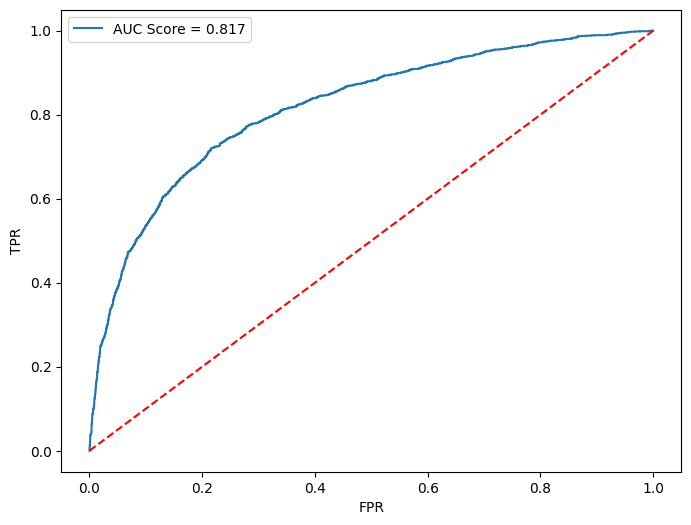

In [170]:
plt.figure(figsize=(8,6))
plt.plot(fpr_smote,tpr_smote,label = f"AUC Score = {auc_smote:.3f}")

plt.plot([0,1],[0,1], linestyle = '--', color='red')

plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.show()